#Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
train_users = pd.read_csv("train_users.csv")
test_users = pd.read_csv("test_users.csv")
news_df = pd.read_csv("news_articles.csv")

print("Train shape:", train_users.shape)
print("Test shape:", test_users.shape)

Train shape: (2000, 33)
Test shape: (2000, 32)


In [3]:
train_users = train_users.drop(columns=["user_id"], errors="ignore")
test_users = test_users.drop(columns=["user_id"], errors="ignore")

for col in train_users.columns:
    if col != "label":
        train_users[col] = pd.to_numeric(train_users[col], errors="ignore")

for col in test_users.columns:
    test_users[col] = pd.to_numeric(test_users[col], errors="ignore")

/tmp/ipython-input-938086117.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  train_users[col] = pd.to_numeric(train_users[col], errors="ignore")
/tmp/ipython-input-938086117.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  test_users[col] = pd.to_numeric(test_users[col], errors="ignore")


In [4]:
X = train_users.drop(columns=["label"])
y = train_users["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [6]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Categorical columns:", categorical_cols)

cat_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

if len(categorical_cols) > 0:
    X_train[categorical_cols] = cat_encoder.fit_transform(
        X_train[categorical_cols]
    )

    X_val[categorical_cols] = cat_encoder.transform(
        X_val[categorical_cols]
    )

Categorical columns: ['browser_version', 'region_code']


In [7]:
print("Object columns left:",
      X_train.select_dtypes(include="object").columns)

Object columns left: Index([], dtype='object')


In [8]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [9]:
val_pred = model.predict(X_val)

print("\nValidation Accuracy:",
      accuracy_score(y_val, val_pred))

print("\nValidation Classification Report:\n")
print(classification_report(
    y_val,
    val_pred,
    target_names=label_encoder.classes_
))


Validation Accuracy: 0.915

Validation Classification Report:

              precision    recall  f1-score   support

      user_1       0.89      0.89      0.89       142
      user_2       0.98      0.89      0.94       142
      user_3       0.88      0.97      0.92       116

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [10]:
X_test = test_users.copy()

if len(categorical_cols) > 0:
    X_test[categorical_cols] = cat_encoder.transform(
        X_test[categorical_cols]
    )

test_predictions = model.predict(X_test)

decoded_predictions = label_encoder.inverse_transform(
    test_predictions
)

print("\nSample Predictions:")
print(decoded_predictions[:20])


Sample Predictions:
['user_2' 'user_1' 'user_1' 'user_1' 'user_1' 'user_3' 'user_3' 'user_1'
 'user_3' 'user_3' 'user_2' 'user_2' 'user_3' 'user_1' 'user_3' 'user_2'
 'user_3' 'user_1' 'user_3' 'user_2']


##Part 2

In [27]:
# INSTALL + LOAD DATA

!pip install rlcmab-sampler

news_df = pd.read_csv("news_articles.csv")
print("Fresh dataset loaded:", len(news_df))

from rlcmab_sampler import sampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

roll_number = 136
reward_sampler = sampler(roll_number)

T = 10000

contexts = ["user_1", "user_2", "user_3"]
categories = ["entertainment", "education", "tech", "crime"]

context_to_index = {
    "user_1": 0,
    "user_2": 1,
    "user_3": 2
}

def get_arm_index(context_id, action):
    return context_id * 4 + action

Fresh dataset loaded: 209527


In [33]:
# DATA CLEANING

news_df["category"] = news_df["category"].str.lower().str.strip()

required_categories = [
    "entertainment",
    "education",
    "tech",
    "crime"
]

news_df = news_df[
    news_df["category"].isin(required_categories)
].copy()

print(news_df["category"].unique())
print(len(news_df))

['tech' 'entertainment' 'education' 'crime']
24042


In [34]:
# CONTEXT GENERATION

def random_context():
    return np.random.randint(0,3)

In [35]:
# EPSILON GREEDY

def run_epsilon_greedy(epsilon):

    Q = np.zeros((3,4))
    N = np.zeros((3,4))
    rewards = np.zeros((3,T))

    for t in range(T):

        c = random_context()

        if np.random.rand() < epsilon:
            a = np.random.randint(4)
        else:
            a = np.argmax(Q[c])

        j = get_arm_index(c,a)
        r = reward_sampler.sample(j)

        N[c,a]+=1
        Q[c,a]+= (r-Q[c,a])/N[c,a]

        rewards[c,t]=r

    return Q,rewards

In [36]:
# UCB


def run_ucb(C):

    Q = np.zeros((3,4))
    N = np.zeros((3,4))
    rewards = np.zeros((3,T))

    for t in range(T):

        c = random_context()

        if 0 in N[c]:
            a = np.argmin(N[c])
        else:
            ucb = Q[c] + C*np.sqrt(
                np.log(t+1)/N[c]
            )
            a = np.argmax(ucb)

        j = get_arm_index(c,a)
        r = reward_sampler.sample(j)

        N[c,a]+=1
        Q[c,a]+= (r-Q[c,a])/N[c,a]

        rewards[c,t]=r

    return Q,rewards

In [37]:
# SOFTMAX (NUMERICALLY SAFE)


def run_softmax(tau=1):

    Q = np.zeros((3,4))
    N = np.zeros((3,4))
    rewards = np.zeros((3,T))

    for t in range(T):

        c = random_context()

        z = Q[c] - np.max(Q[c])
        exp = np.exp(z/tau)
        probs = exp/np.sum(exp)

        a = np.random.choice(4,p=probs)

        j = get_arm_index(c,a)
        r = reward_sampler.sample(j)

        N[c,a]+=1
        Q[c,a]+= (r-Q[c,a])/N[c,a]

        rewards[c,t]=r

    return Q,rewards

In [38]:
# RUN EXPERIMENTS

eps_values=[0.05,0.1,0.2]
ucb_values=[0.5,1,2]

eps_results={}
for e in eps_values:
    print("Running epsilon:",e)
    eps_results[e]=run_epsilon_greedy(e)

ucb_results={}
for c in ucb_values:
    print("Running UCB:",c)
    ucb_results[c]=run_ucb(c)

softmax_Q,softmax_rewards=run_softmax()

Running epsilon: 0.05
Running epsilon: 0.1
Running epsilon: 0.2
Running UCB: 0.5
Running UCB: 1
Running UCB: 2


In [39]:
# FINAL POLICY

final_Q=eps_results[0.1][0]
print(final_Q)

[[-6.3107614   6.12024217 -1.95477195 -2.45681486]
 [-7.78926172  1.03749367 -6.86621364  8.37461645]
 [ 4.12391862 -1.39881757 -7.06238077 -0.56036553]]


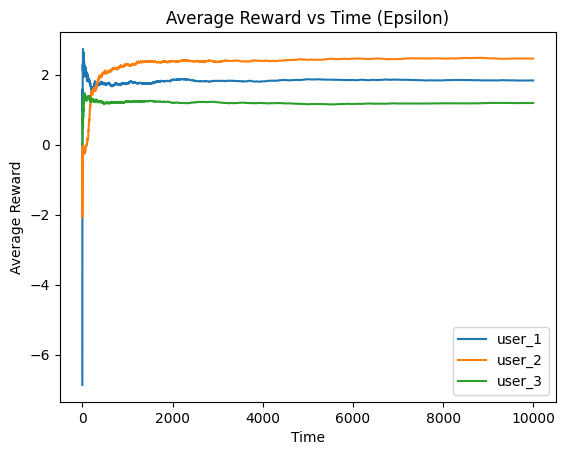

In [40]:
# EPSILON REWARD PLOT

for ctx in range(3):

    avg=np.cumsum(
        eps_results[0.1][1][ctx]
    )/(np.arange(T)+1)

    plt.plot(avg,label=contexts[ctx])

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time (Epsilon)")
plt.legend()
plt.show()

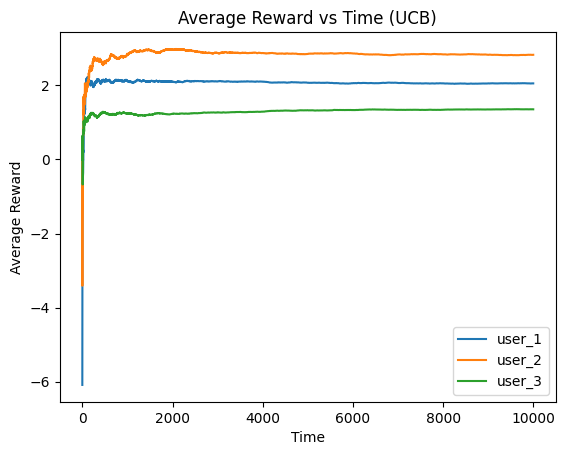

In [41]:
# UCB REWARD PLOT

for ctx in range(3):

    avg=np.cumsum(
        ucb_results[1][1][ctx]
    )/(np.arange(T)+1)

    plt.plot(avg,label=contexts[ctx])

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time (UCB)")
plt.legend()
plt.show()

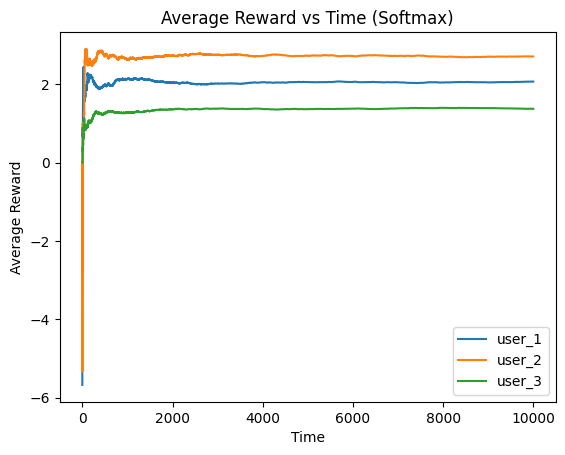

In [42]:
# SOFTMAX REWARD PLOT
for ctx in range(3):

    avg=np.cumsum(
        softmax_rewards[ctx]
    )/(np.arange(T)+1)

    plt.plot(avg,label=contexts[ctx])

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time (Softmax)")
plt.legend()
plt.show()

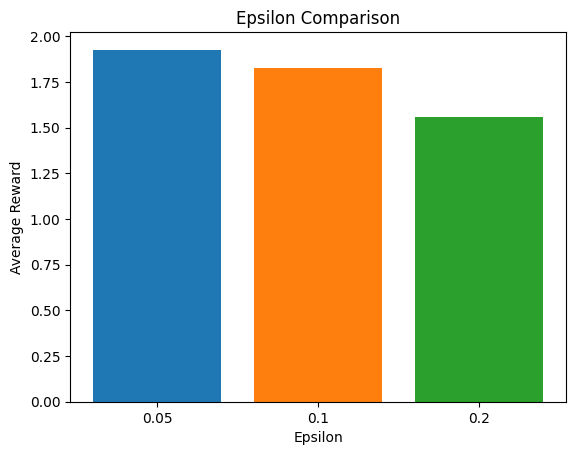

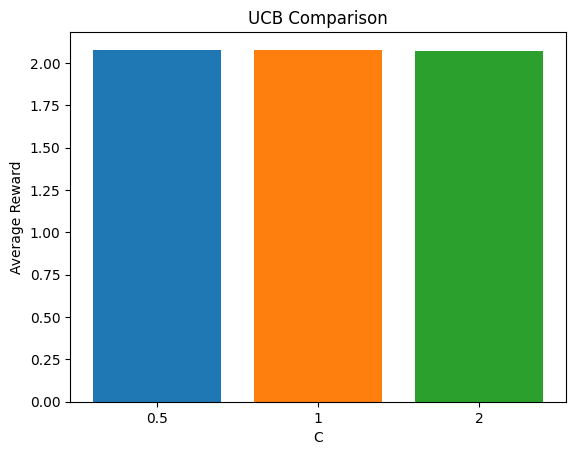

In [43]:
# PARAMETER COMPARISON

for e in eps_values:
    avg=np.mean(eps_results[e][1])
    plt.bar(str(e),avg)

plt.xlabel("Epsilon")
plt.ylabel("Average Reward")
plt.title("Epsilon Comparison")
plt.show()

for c in ucb_values:
    avg=np.mean(ucb_results[c][1])
    plt.bar(str(c),avg)

plt.xlabel("C")
plt.ylabel("Average Reward")
plt.title("UCB Comparison")
plt.show()

In [44]:
# ARTICLE RECOMMENDER

def recommend_article(user_row):

    user_df = pd.DataFrame([user_row])

    if len(categorical_cols) > 0:
        user_df[categorical_cols] = cat_encoder.transform(
            user_df[categorical_cols]
        )

    pred = model.predict(user_df)[0]
    context = label_encoder.inverse_transform([pred])[0]

    context_id = context_to_index[context]

    action = np.argmax(final_Q[context_id])
    category = categories[action]

    news_df["category"] = news_df["category"].str.lower().str.strip()

    filtered = news_df[
        news_df["category"] == category
    ]

    if len(filtered)==0:
        print("WARNING: No articles found for:",category)
        print("Available:",news_df["category"].unique())
        return context,category,None

    article = filtered.sample(n=1).iloc[0]

    return context, category, article

In [45]:
# TEST RECOMMENDATION

sample_user=test_users.iloc[0]

context,category,article=recommend_article(sample_user)

print("Predicted Context:",context)
print("Recommended Category:",category)
print(article)

Predicted Context: user_2
Recommended Category: crime
link                 https://www.huffingtonpost.com/entry/college-f...
headline             College Football Player Used Drugs Before Texa...
category                                                         crime
short_description                  Does that justify the use of force?
authors                                EMILY SCHMALL, Associated Press
date                                                        2015-09-02
Name: 89932, dtype: object
